In [150]:
#載入套件
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
%matplotlib inline

In [151]:
#匯入資料（但所有變數名稱皆是隱藏，但需要預測最後TARGET CLASS是哪個）
#index_col=0代表設定第一行為index
df = pd.read_csv('data/Classified Data',index_col=0)
print(df.shape)
print(df.head())
X = df.drop("TARGET CLASS", axis = 1)
y = df["TARGET CLASS"]
print(X.shape)
print(y)

y.value_counts()

(1000, 11)
        WTT       PTI       EQW       SBI       LQE       QWG       FDJ  \
0  0.913917  1.162073  0.567946  0.755464  0.780862  0.352608  0.759697   
1  0.635632  1.003722  0.535342  0.825645  0.924109  0.648450  0.675334   
2  0.721360  1.201493  0.921990  0.855595  1.526629  0.720781  1.626351   
3  1.234204  1.386726  0.653046  0.825624  1.142504  0.875128  1.409708   
4  1.279491  0.949750  0.627280  0.668976  1.232537  0.703727  1.115596   

        PJF       HQE       NXJ  TARGET CLASS  
0  0.643798  0.879422  1.231409             1  
1  1.013546  0.621552  1.492702             0  
2  1.154483  0.957877  1.285597             0  
3  1.380003  1.522692  1.153093             1  
4  0.646691  1.463812  1.419167             1  
(1000, 10)
0      1
1      0
2      0
3      1
4      1
      ..
995    1
996    0
997    1
998    1
999    1
Name: TARGET CLASS, Length: 1000, dtype: int64


TARGET CLASS
1    500
0    500
Name: count, dtype: int64

In [152]:
#將資料分成訓練組及測試組
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 101, stratify = y)

In [153]:
#由於KNN分類法是藉由確認最近的觀察值來預測分類，因此變數的比例就會影響很大
#載入標準化比例尺(StandardScaler)套件，只將所有`特徵值`做標準化
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [154]:
#使用KNN演算法
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors = 1)
neigh.fit(X_train_scaled, y_train)
y_test_pred = neigh.predict(X_test_scaled)
#從k=1開始測試


In [155]:
#測試KNN演算法的好壞
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_test_pred))

[[136  14]
 [ 17 133]]


In [156]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90       150
           1       0.90      0.89      0.90       150

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300



In [161]:
#利用 for 迴圈找 k 最佳值

train_accuracy = []
test_accuracy = []

k_range = range(1, 60)

for k in k_range:
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X_train_scaled, y_train)

    y_train_pred = neigh.predict(X_train_scaled)
    y_test_pred = neigh.predict(X_test_scaled)

    train_accuracy.append(metrics.accuracy_score(y_train, y_train_pred))
    test_accuracy.append(metrics.accuracy_score(y_test, y_test_pred))

best_k = list(k_range)[np.argmax(test_accuracy)]
best_score = max(test_accuracy)

print("最佳 k（以本次 test accuracy 來看）:", best_k)
print("最佳 test accuracy:", round(best_score, 3))

最佳 k（以本次 test accuracy 來看）: 36
最佳 test accuracy: 0.93


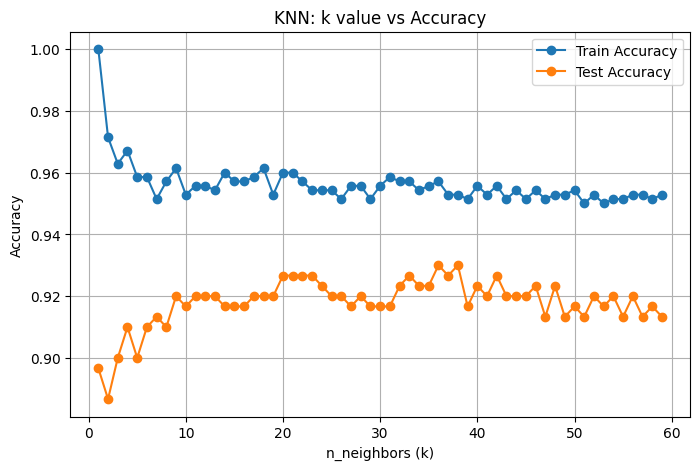

In [162]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, train_accuracy, marker='o', label='Train Accuracy')
plt.plot(k_range, test_accuracy, marker='o', label='Test Accuracy')
plt.xlabel("n_neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN: k value vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [157]:
#剛剛只先用了k=1來建立模型，現在利用for來建立迴圈(選擇不同k值)，並紀錄錯誤率
error_rate = []

for k in range(1, 60):
    neigh_k = KNeighborsClassifier(n_neighbors=k)
    neigh_k.fit(X_train_scaled, y_train)
    pred_k = neigh_k.predict(X_test_scaled)
    error_rate.append(np.mean(pred_k != y_test))

Text(0, 0.5, 'Error Rate')

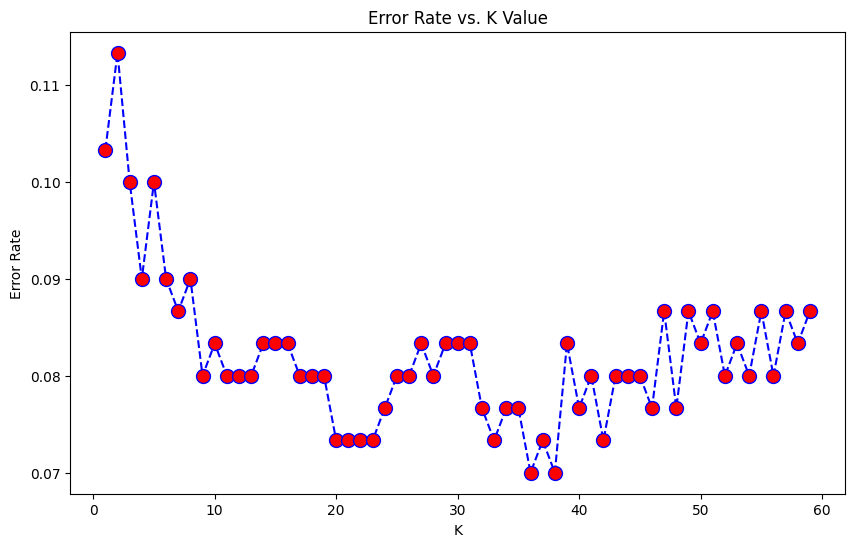

In [158]:
#將k=1~60的錯誤率製圖畫出。k=23之後，錯誤率就在5-6%之間震盪。
plt.figure(figsize=(10,6))
plt.plot(range(1,60),error_rate,color='blue',linestyle='dashed',marker='o',markerfacecolor='red',markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [159]:
#跟一開始k=1做比較

print('WITH k=1')
print('\n')
print(confusion_matrix(y_test, y_test_pred))
print('\n')
print(classification_report(y_test, y_test_pred))

WITH k=1


[[136  14]
 [ 17 133]]


              precision    recall  f1-score   support

           0       0.89      0.91      0.90       150
           1       0.90      0.89      0.90       150

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300



In [160]:
#選擇錯誤率最低的K=?????來看precision、recall、f1-score、support表現

neigh_36 = KNeighborsClassifier(n_neighbors = 36)
neigh_36.fit(X_train_scaled, y_train)
y_test_pred_36 = neigh_36.predict(X_test_scaled)

print('WITH k=36')
print('\n')
print(confusion_matrix(y_test, y_test_pred_36))
print('\n')
print(classification_report(y_test, y_test_pred_36))

WITH k=36


[[138  12]
 [  9 141]]


              precision    recall  f1-score   support

           0       0.94      0.92      0.93       150
           1       0.92      0.94      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300

